# Data Generation: Handwritten Word Images → Stroke Trajectories

Generates paired training data for an image-to-stroke model:
- **Input**: Rasterized handwritten word image (with augmentations)
- **Target**: Normalized stroke trajectory `(dx, dy, pen_state)`

Uses the [Decoupled Style Descriptors](https://github.com/brownvc/decoupled-style-descriptors) model to synthesize diverse handwriting across multiple writer styles.

## 1. Setup & Model Loading

In [1]:
import os, sys, json, random, io
import numpy as np
import torch
from PIL import Image, ImageDraw, ImageFilter, ImageEnhance, ImageFont
from scipy import ndimage
from tqdm.notebook import tqdm

REPO_DIR = os.path.join(os.getcwd(), "decoupled-style-descriptors")
sys.path.insert(0, REPO_DIR)

from SynthesisNetwork import SynthesisNetwork
from DataLoader import DataLoader
import convenience
from config.GlobalVariables import CHARACTERS

device = "cpu"

# Load model
net = SynthesisNetwork(weight_dim=256, num_layers=3).to(device)
checkpoint = torch.load(os.path.join(REPO_DIR, "model", "250000.pt"), map_location=device)
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    net.load_state_dict(checkpoint["model_state_dict"])
else:
    net.load_state_dict(checkpoint)
net.eval()

# Load writer data
DATA_DIR = os.path.join(REPO_DIR, "data", "writers")
dl = DataLoader(num_writer=1, num_samples=10, divider=5.0, datadir=DATA_DIR)

# Get actual writer directory IDs (they're not 0-indexed)
WRITER_IDS = sorted([int(name) for name in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, name))])
print(f"Model loaded. {len(WRITER_IDS)} writers available: {WRITER_IDS}")

# Pre-load all writer data for fast sampling
writer_cache = {}
for wid in WRITER_IDS:
    num_texts = len(os.listdir(os.path.join(DATA_DIR, str(wid))))
    tids = list(range(min(10, num_texts)))
    writer_cache[wid] = dl.next_batch(TYPE="TRAIN", uid=wid, tids=tids)
print(f"Cached data for {len(writer_cache)} writers.")

self.datadir :  /Users/artemlukoyanov/Documents/Proga/Ilumni/playground/SundaiClub/weeks/inkai/ink-ai-hack-playground/notebooks/decoupled-style-descriptors/data/writers
Model loaded. 12 writers available: [5, 14, 15, 16, 17, 22, 25, 80, 120, 137, 147, 151]
Cached data for 12 writers.


## 2. Word List & Sampling

In [2]:
WORD_LIST = [
    "the", "be", "to", "of", "and", "a", "in", "that", "have", "it",
    "for", "not", "on", "with", "he", "as", "you", "do", "at", "this",
    "but", "his", "by", "from", "they", "we", "say", "her", "she", "or",
    "an", "will", "my", "one", "all", "would", "there", "their", "what",
    "so", "up", "out", "if", "about", "who", "get", "which", "go", "me",
    "when", "make", "can", "like", "time", "no", "just", "him", "know",
    "take", "people", "into", "year", "your", "good", "some", "could",
    "them", "see", "other", "than", "then", "now", "look", "only", "come",
    "its", "over", "think", "also", "back", "after", "use", "two", "how",
    "our", "work", "first", "well", "way", "even", "new", "want", "because",
    "any", "these", "give", "day", "most", "us", "great", "between", "need",
    "large", "often", "hand", "high", "place", "hold", "free", "real",
    "life", "few", "north", "open", "seem", "together", "next", "white",
    "children", "begin", "got", "walk", "example", "ease", "paper", "group",
    "always", "music", "those", "both", "mark", "book", "letter", "until",
    "mile", "river", "car", "feet", "care", "second", "enough", "plain",
    "girl", "usual", "young", "ready", "above", "ever", "red", "list",
    "though", "feel", "talk", "bird", "soon", "body", "dog", "family",
    "direct", "pose", "leave", "song", "measure", "door", "product", "black",
    "short", "number", "class", "wind", "question", "happen", "complete",
    "ship", "area", "half", "rock", "order", "fire", "south", "problem",
    "piece", "told", "knew", "pass", "since", "top", "whole", "king",
    "space", "heard", "best", "hour", "better", "true", "during", "hundred",
    "five", "remember", "step", "early", "left", "bring", "seem",
    "light", "study", "run", "small", "end", "put", "home", "read",
    "start", "might", "story", "saw", "far", "sea", "draw", "earth",
    "near", "build", "self", "keep", "food", "never", "quite", "along",
    "might", "close", "point", "form", "name", "live", "play", "move",
    "still", "learn", "plant", "cover", "state", "rain", "try", "answer",
    "hard", "set", "turn", "old", "right", "off", "came", "did", "side",
    "world", "long", "three", "made", "find", "here", "thing", "many",
    "went", "part", "write", "call", "head", "eye", "line", "face",
    "show", "own", "under", "last", "ask", "went", "man", "act", "tree",
    "city", "note", "change", "help", "much", "same", "tell", "does",
    "lead", "dark", "kind", "cut", "must", "lot", "big", "word", "each",
    "below", "air", "table", "every", "reach", "fast", "low", "blue",
    "voice", "sing", "deep", "fish", "late", "warm", "cold", "sure",
    "clear", "rise", "sort", "base", "pull", "test", "once", "love",
    "sun", "art", "heat", "age", "ten", "simple", "stand", "round",
    "page", "gold", "plan", "grow", "size", "hot", "pick", "sleep",
    "iron", "drop", "push", "copy", "spoke", "horse", "snow", "tire",
    "thick", "fill", "east", "paint", "spring", "wild", "rest", "mix",
    "glad", "soft", "green", "hunt", "lake", "trade", "inch", "joy",
    "path", "bank", "fine", "jump", "queen", "rose", "safe", "mine",
    "skin", "cloud", "beat", "wash", "nine", "feed", "bone", "rich",
    "wave", "flat", "stone", "sharp", "spell", "port", "smell", "rain",
    "match", "shape", "star", "seed", "swim", "tool", "wide", "dress",
    "beach", "brown", "clean", "ring", "sail", "quiet", "press", "corn",
    "camp", "band", "roll", "wish", "ball", "type", "chair", "root",
    "nose", "wing", "fight", "chain", "coat", "cool", "dark", "farm",
    "grand", "basic", "count", "dream", "equal", "field", "final", "fresh",
    "fruit", "guide", "happy", "ideal", "joint", "lunch", "month", "moral",
    "novel", "peace", "prime", "proof", "quick", "rough", "seven", "sight",
    "solid", "south", "sugar", "super", "theme", "third", "title", "total",
    "track", "upper", "video", "worth", "adult", "apart", "blind", "block",
    "brain", "broad", "cable", "cheap", "check", "chief", "clock", "crazy",
    "cross", "cycle", "daily", "enemy", "error", "exact", "fault", "floor",
    "front", "glass", "guard", "hello", "honor", "human", "inner", "knife",
    "layer", "legal", "limit", "magic", "metal", "model", "night", "noise",
    "ocean", "offer", "owner", "paint", "panel", "pilot", "pitch", "plain",
    "plate", "pound", "pride", "print", "prize", "ratio", "reply", "rider",
    "river", "rough", "royal", "scale", "scene", "score", "serve", "shake",
    "sheet", "shelf", "shift", "shirt", "shock", "sight", "skill", "sleep",
    "slide", "smile", "smoke", "solar", "sound", "spare", "speak", "spend",
    "split", "sport", "spray", "squad", "staff", "stage", "stake", "steam",
    "steel", "stick", "stock", "storm", "strip", "stuff", "sugar", "super",
    "sweet", "taste", "teach", "theft", "those", "tight", "timer", "tired",
    "token", "touch", "tough", "tower", "trace", "train", "trend", "trial",
    "tribe", "trick", "truck", "truly", "trust", "twice", "under", "union",
    "urban", "usual", "valid", "virus", "vital", "vocal", "waste", "water",
    "wheat", "whole", "woman", "youth",
]

# Deduplicate and filter to lowercase a-z only
WORD_LIST = sorted(set(w for w in WORD_LIST if all(c in "abcdefghijklmnopqrstuvwxyz" for c in w)))
print(f"{len(WORD_LIST)} unique words available")

def sample_words(n):
    """Sample n random words from the word list."""
    return [random.choice(WORD_LIST) for _ in range(n)]

# Preview
print("Sample words:", sample_words(15))

561 unique words available
Sample words: ['ask', 'test', 'mine', 'bring', 'cut', 'hunt', 'clear', 'cover', 'base', 'wave', 'virus', 'ten', 'space', 'sound', 'feed']


## 3. Trajectory Generation

Generate stroke commands `(x, y, pen_state)` for a word using the DSD model with random writer style.

In [3]:
def generate_trajectory(word, writer_ids=None, blend_weight=None, scale_sd=None):
    """Generate a stroke trajectory for a single word.
    
    Returns:
        commands: np.ndarray (N, 3) of absolute (x, y, pen_up_flag)
        writer_ids: list of writer IDs used
        blend_weight: float blend weight used (None if single writer)
    """
    if writer_ids is None:
        # Randomly pick 1 or 2 writers from available WRITER_IDS
        if random.random() < 0.4:
            writer_ids = [random.choice(WRITER_IDS)]
        else:
            writer_ids = random.sample(WRITER_IDS, 2)
    
    if blend_weight is None and len(writer_ids) == 2:
        blend_weight = random.random()
    
    # Set MDN sampling temperature for variety
    if scale_sd is not None:
        net.scale_sd = scale_sd
    else:
        net.scale_sd = random.uniform(0.0, 0.3)
    net.clamp_mdn = 0.0
    
    all_loaded_data = [writer_cache[wid] for wid in writer_ids]
    
    # Compute writer style vectors
    writer_mean_Ws = []
    for loaded_data in all_loaded_data:
        mean_W = convenience.get_mean_global_W(net, loaded_data, device)
        writer_mean_Ws.append(mean_W)
    
    # Get style descriptors for the word
    writer_Ws, writer_Cs = convenience.get_DSD(net, word, writer_mean_Ws, all_loaded_data, device)
    
    # Blend writer styles
    if len(writer_ids) == 1:
        weights = [1.0]
    else:
        weights = [1.0 - blend_weight, blend_weight]
    
    all_W_c = convenience.get_writer_blend_W_c(weights, writer_Ws, writer_Cs)
    
    # Generate stroke commands
    with torch.no_grad():
        commands = convenience.get_commands(net, word, all_W_c)
    
    return commands, writer_ids, blend_weight


# Test: generate a single word
test_cmds, test_wids, test_blend = generate_trajectory("hello")
print(f"Generated 'hello': {test_cmds.shape[0]} points, writers={test_wids}, blend={test_blend}")
print(f"Command range: x=[{test_cmds[:,0].min():.1f}, {test_cmds[:,0].max():.1f}], y=[{test_cmds[:,1].min():.1f}, {test_cmds[:,1].max():.1f}]")

Generated 'hello': 66 points, writers=[151], blend=None
Command range: x=[0.0, 102.8], y=[59.0, 103.2]


## 4. Trajectory Normalization

Convert absolute `(x, y, pen_state)` to normalized `(dx, dy, pen_state)` deltas for ML training.

In [4]:
def normalize_trajectory(commands):
    """Convert absolute commands to normalized deltas.
    
    Input: (N, 3) absolute (x, y, pen_state)
    Output: (N, 3) normalized (dx, dy, pen_state) where deltas are scaled so height=1.0
    
    Also returns normalization params for inverse transform.
    """
    xy = commands[:, :2].copy()
    pen = commands[:, 2:3].copy()
    
    # Compute deltas (first point is relative to origin)
    deltas = np.zeros_like(xy)
    deltas[0] = xy[0]
    deltas[1:] = xy[1:] - xy[:-1]
    
    # Scale by bounding box height for normalization
    y_range = xy[:, 1].max() - xy[:, 1].min()
    x_range = xy[:, 0].max() - xy[:, 0].min()
    
    scale = max(y_range, 1.0)  # avoid division by zero
    deltas /= scale
    
    norm_params = {
        "scale": float(scale),
        "x_min": float(xy[:, 0].min()),
        "y_min": float(xy[:, 1].min()),
        "x_range": float(x_range),
        "y_range": float(y_range),
    }
    
    return np.concatenate([deltas, pen], axis=1).astype(np.float32), norm_params


def denormalize_trajectory(norm_deltas, norm_params):
    """Inverse of normalize_trajectory: reconstruct absolute commands from deltas."""
    deltas = norm_deltas[:, :2] * norm_params["scale"]
    pen = norm_deltas[:, 2:3]
    
    # Cumulative sum to get absolute positions
    xy = np.cumsum(deltas, axis=0)
    
    return np.concatenate([xy, pen], axis=1)


# Test round-trip
norm, params = normalize_trajectory(test_cmds)
reconstructed = denormalize_trajectory(norm, params)
error = np.abs(test_cmds[:, :2] - reconstructed[:, :2]).max()
print(f"Normalization round-trip max error: {error:.6f}")
print(f"Normalized delta range: dx=[{norm[:,0].min():.3f}, {norm[:,0].max():.3f}], dy=[{norm[:,1].min():.3f}, {norm[:,1].max():.3f}]")
print(f"Norm params: {params}")

Normalization round-trip max error: 0.000036
Normalized delta range: dx=[-0.179, 0.608], dy=[-0.857, 1.513]
Norm params: {'scale': 44.25648856908083, 'x_min': 0.0, 'y_min': 58.9883727702545, 'x_range': 102.7674177911831, 'y_range': 44.25648856908083}


## 5. Image Augmentations

Creative augmentations to make rasterized images look like real photos of handwriting on paper.

In [5]:
IMG_W, IMG_H = 192, 64  # output image size

# --- Ink colors (R, G, B) ---
INK_COLORS = [
    (10, 10, 10),       # black
    (20, 20, 80),       # dark blue
    (50, 50, 50),       # dark gray
    (60, 30, 10),       # dark brown
    (10, 10, 120),      # blue ink
    (80, 10, 10),       # dark red
    (30, 60, 30),       # dark green
]

# --- Background generators ---

def bg_plain(w, h):
    """Plain colored background."""
    color = random.choice([
        (255, 255, 255),  # white
        (252, 248, 230),  # cream
        (255, 253, 208),  # light yellow
        (240, 240, 240),  # light gray
        (230, 235, 245),  # light blue-gray
        (245, 235, 225),  # warm beige
    ])
    return Image.new("RGB", (w, h), color)


def bg_lined(w, h):
    """Lined notebook paper."""
    bg_color = random.choice([(255, 255, 255), (252, 248, 230), (245, 245, 250)])
    line_color = random.choice([
        (180, 210, 240),  # blue lines
        (200, 200, 200),  # gray lines
        (210, 190, 190),  # pink lines
    ])
    img = Image.new("RGB", (w, h), bg_color)
    dr = ImageDraw.Draw(img)
    spacing = random.randint(8, 14)
    offset = random.randint(0, spacing)
    for y in range(offset, h, spacing):
        dr.line([(0, y), (w, y)], fill=line_color, width=1)
    return img


def bg_grid(w, h):
    """Grid paper background."""
    bg_color = (255, 255, 255)
    grid_color = (210, 230, 210)  # light green
    img = Image.new("RGB", (w, h), bg_color)
    dr = ImageDraw.Draw(img)
    spacing = random.randint(8, 14)
    for y in range(0, h, spacing):
        dr.line([(0, y), (w, y)], fill=grid_color, width=1)
    for x in range(0, w, spacing):
        dr.line([(x, 0), (x, h)], fill=grid_color, width=1)
    return img


def bg_noisy(w, h):
    """Paper texture with Perlin-like noise."""
    base_color = np.array(random.choice([
        [255, 255, 255], [250, 245, 230], [245, 240, 235]
    ]), dtype=np.float32)
    noise = np.random.randn(h, w).astype(np.float32)
    # Multi-scale noise for paper texture
    smooth1 = ndimage.gaussian_filter(noise, sigma=3.0) * 8
    smooth2 = ndimage.gaussian_filter(noise, sigma=0.8) * 3
    texture = smooth1 + smooth2
    pixels = np.clip(
        base_color[None, None, :] + texture[:, :, None],
        0, 255
    ).astype(np.uint8)
    return Image.fromarray(pixels)


BG_GENERATORS = [bg_plain, bg_lined, bg_grid, bg_noisy]


# --- Stroke rendering ---

def render_strokes_on_image(commands, bg_img, ink_color, stroke_width):
    """Render stroke commands onto a background image.
    
    Fits the strokes into the image with padding, then draws them.
    Returns the image with strokes rendered.
    """
    img = bg_img.copy()
    dr = ImageDraw.Draw(img)
    w, h = img.size
    
    # Fit commands into image with padding
    pad = max(8, stroke_width * 2)
    xs, ys = commands[:, 0], commands[:, 1]
    x_min, x_max = xs.min(), xs.max()
    y_min, y_max = ys.min(), ys.max()
    
    src_w = max(x_max - x_min, 1)
    src_h = max(y_max - y_min, 1)
    
    # Scale to fit with padding, preserving aspect ratio
    scale = min((w - 2 * pad) / src_w, (h - 2 * pad) / src_h)
    
    # Center in image
    scaled_w = src_w * scale
    scaled_h = src_h * scale
    off_x = (w - scaled_w) / 2
    off_y = (h - scaled_h) / 2
    
    def transform(x, y):
        return (
            (x - x_min) * scale + off_x,
            (y - y_min) * scale + off_y,
        )
    
    # Draw strokes
    px, py = transform(commands[0, 0], commands[0, 1])
    for i in range(1, len(commands)):
        x, y = transform(commands[i, 0], commands[i, 1])
        if commands[i - 1, 2] == 0:  # pen was down
            dr.line([(px, py), (x, y)], fill=ink_color, width=stroke_width)
        px, py = x, y
    
    return img


# --- Appearance-only augmentations (no geometric transforms) ---

def augment_blur(img):
    """Gaussian blur."""
    radius = random.uniform(0, 1.2)
    return img.filter(ImageFilter.GaussianBlur(radius=radius))


def augment_noise(img):
    """Gaussian noise."""
    arr = np.array(img).astype(np.float32)
    noise = np.random.randn(*arr.shape) * random.uniform(1, 8)
    arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(arr)


def augment_brightness_contrast(img):
    """Random brightness and contrast."""
    brightness = random.uniform(0.85, 1.15)
    contrast = random.uniform(0.85, 1.15)
    img = ImageEnhance.Brightness(img).enhance(brightness)
    img = ImageEnhance.Contrast(img).enhance(contrast)
    return img


def augment_ink_bleed(img):
    """Morphological dilation to simulate ink spreading."""
    arr = np.array(img)
    dark_mask = arr.mean(axis=2) < 128
    if dark_mask.sum() < 10:
        return img
    kernel_size = random.choice([1, 2])
    dilated = ndimage.minimum_filter(arr, size=(kernel_size, kernel_size, 1))
    result = np.where(dark_mask[:, :, None], dilated, arr)
    return Image.fromarray(result.astype(np.uint8))


def augment_jpeg_artifacts(img):
    """JPEG compression artifacts."""
    quality = random.randint(50, 90)
    buffer = io.BytesIO()
    img.save(buffer, format="JPEG", quality=quality)
    buffer.seek(0)
    return Image.open(buffer).convert("RGB")


def apply_augmentations(img):
    """Apply a random subset of appearance-only augmentations."""
    img = augment_brightness_contrast(img)
    
    if random.random() < 0.5:
        img = augment_blur(img)
    if random.random() < 0.4:
        img = augment_noise(img)
    if random.random() < 0.3:
        img = augment_ink_bleed(img)
    if random.random() < 0.2:
        img = augment_jpeg_artifacts(img)
    
    return img


# --- Full rasterization pipeline ---

def rasterize_with_augmentations(commands):
    """Render stroke commands to an augmented image."""
    bg_gen = random.choice(BG_GENERATORS)
    bg = bg_gen(IMG_W, IMG_H)
    ink_color = random.choice(INK_COLORS)
    stroke_width = random.randint(1, 3)
    
    img = render_strokes_on_image(commands, bg, ink_color, stroke_width)
    img = apply_augmentations(img)
    
    return img


print("Augmentation pipeline ready (appearance-only, no geometric transforms).")

Augmentation pipeline ready (appearance-only, no geometric transforms).


### Preview augmentations

Interactive preview: pick a word and toggle augmentations on/off.

In [ ]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Controls ---
word_input = widgets.Text(value="hello", description="Word:")
bg_dropdown = widgets.Dropdown(
    options=["random", "plain", "lined", "grid", "noisy"],
    value="random", description="Background:"
)
ink_dropdown = widgets.Dropdown(
    options=["random", "black", "blue", "gray", "brown", "blue ink", "red", "green"],
    value="random", description="Ink color:"
)
stroke_w_slider = widgets.IntSlider(value=0, min=0, max=4, description="Stroke width:", style={"description_width": "initial"})
stroke_w_slider_label = widgets.Label("(0 = random)")

toggle_blur = widgets.Checkbox(value=True, description="Gaussian blur")
toggle_noise = widgets.Checkbox(value=True, description="Pixel noise")
toggle_ink_bleed = widgets.Checkbox(value=True, description="Ink bleed")
toggle_jpeg = widgets.Checkbox(value=True, description="JPEG artifacts")
toggle_brightness = widgets.Checkbox(value=True, description="Brightness/contrast")

generate_btn = widgets.Button(description="Generate 12 samples", button_style="primary")
output = widgets.Output()

BG_MAP = {"plain": bg_plain, "lined": bg_lined, "grid": bg_grid, "noisy": bg_noisy}
INK_MAP = {
    "black": (10, 10, 10), "blue": (20, 20, 80), "gray": (50, 50, 50),
    "brown": (60, 30, 10), "blue ink": (10, 10, 120), "red": (80, 10, 10), "green": (30, 60, 30),
}

def generate_preview(_=None):
    with output:
        clear_output(wait=True)
        word = word_input.value.strip().lower()
        if not word:
            print("Enter a word!")
            return
        
        fig, axes = plt.subplots(3, 4, figsize=(16, 6))
        fig.suptitle(f"'{word}' — random writers & augmentations", fontsize=14)
        
        for ax in axes.flat:
            cmds, wids_used, blend = generate_trajectory(word)
            
            # Background
            if bg_dropdown.value == "random":
                bg = random.choice(BG_GENERATORS)(IMG_W, IMG_H)
            else:
                bg = BG_MAP[bg_dropdown.value](IMG_W, IMG_H)
            
            # Ink color
            if ink_dropdown.value == "random":
                ink = random.choice(INK_COLORS)
            else:
                ink = INK_MAP[ink_dropdown.value]
            
            # Stroke width
            sw = stroke_w_slider.value if stroke_w_slider.value > 0 else random.randint(1, 3)
            
            img = render_strokes_on_image(cmds, bg, ink, sw)
            
            # Selective augmentations
            if toggle_brightness.value:
                img = augment_brightness_contrast(img)
            if toggle_blur.value and random.random() < 0.5:
                img = augment_blur(img)
            if toggle_noise.value and random.random() < 0.4:
                img = augment_noise(img)
            if toggle_ink_bleed.value and random.random() < 0.3:
                img = augment_ink_bleed(img)
            if toggle_jpeg.value and random.random() < 0.2:
                img = augment_jpeg_artifacts(img)
            
            ax.imshow(img)
            label = f"w{wids_used}"
            if blend is not None:
                label += f" b={blend:.2f}"
            ax.set_title(label, fontsize=8)
            ax.axis("off")
        
        plt.tight_layout()
        plt.show()

generate_btn.on_click(generate_preview)

display(widgets.VBox([
    word_input,
    widgets.HBox([bg_dropdown, ink_dropdown, widgets.HBox([stroke_w_slider, stroke_w_slider_label])]),
    widgets.Label("Augmentations (appearance-only):"),
    widgets.HBox([toggle_blur, toggle_noise, toggle_ink_bleed, toggle_jpeg, toggle_brightness]),
    generate_btn,
    output,
]))

## 6. Dataset Generation Pipeline

Configure and run the full generation loop.

In [14]:
# --- Configuration ---
NUM_SAMPLES = 2000
MAX_SEQ_LEN = 300       # pad/truncate trajectories to this length
OUTPUT_DIR = os.path.join(os.getcwd(), "data", "generated")
SAVE_INDIVIDUAL = True  # save per-sample .png and .npz files
PREVIEW_EVERY = 500     # show preview grid every N samples

os.makedirs(os.path.join(OUTPUT_DIR, "images"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "trajectories"), exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")

Output directory: /Users/artemlukoyanov/Documents/Proga/Ilumni/playground/SundaiClub/weeks/inkai/ink-ai-hack-playground/notebooks/data/generated


In [ ]:
def pad_or_truncate(traj, max_len):
    """Pad trajectory to max_len or truncate if longer."""
    n = len(traj)
    if n >= max_len:
        return traj[:max_len], max_len
    padded = np.zeros((max_len, 3), dtype=np.float32)
    padded[:n] = traj
    # Pad with pen-up state
    padded[n:, 2] = 1.0
    return padded, n


# Batched arrays for the full dataset
all_images = np.zeros((NUM_SAMPLES, IMG_H, IMG_W, 3), dtype=np.uint8)
all_trajectories = np.zeros((NUM_SAMPLES, MAX_SEQ_LEN, 3), dtype=np.float32)
all_lengths = np.zeros(NUM_SAMPLES, dtype=np.int32)
all_words = []
all_writer_info = []
failed_words = []

sample_idx = 0
words_to_generate = sample_words(NUM_SAMPLES * 2)  # oversample in case of failures
word_iter = iter(words_to_generate)

pbar = tqdm(total=NUM_SAMPLES, desc="Generating samples")

while sample_idx < NUM_SAMPLES:
    try:
        word = next(word_iter)
    except StopIteration:
        # If we exhaust the word list, sample more
        words_to_generate = sample_words(NUM_SAMPLES)
        word_iter = iter(words_to_generate)
        word = next(word_iter)
    
    try:
        # Generate trajectory
        commands, writer_ids, blend_weight = generate_trajectory(word)
        
        # Sanity checks
        if len(commands) < 5 or len(commands) > 2000:
            failed_words.append((word, "bad length"))
            continue
        if np.any(np.isnan(commands)) or np.any(np.isinf(commands)):
            failed_words.append((word, "nan/inf"))
            continue
        
        # Normalize trajectory
        norm_traj, norm_params = normalize_trajectory(commands)
        padded_traj, actual_len = pad_or_truncate(norm_traj, MAX_SEQ_LEN)
        
        # Rasterize with augmentations
        img = rasterize_with_augmentations(commands)
        img_arr = np.array(img)
        
        # Store in batch arrays
        all_images[sample_idx] = img_arr
        all_trajectories[sample_idx] = padded_traj
        all_lengths[sample_idx] = actual_len
        all_words.append(word)
        all_writer_info.append({
            "writer_ids": writer_ids,
            "blend_weight": blend_weight,
            "norm_params": norm_params,
        })
        
        # Save individual files
        if SAVE_INDIVIDUAL:
            img.save(os.path.join(OUTPUT_DIR, "images", f"{sample_idx:06d}.png"))
            np.savez_compressed(
                os.path.join(OUTPUT_DIR, "trajectories", f"{sample_idx:06d}.npz"),
                trajectory=padded_traj,
                length=actual_len,
                word=word,
                writer_ids=writer_ids,
                blend_weight=blend_weight if blend_weight is not None else -1.0,
                norm_scale=norm_params["scale"],
            )
        
        # Periodic preview
        if sample_idx > 0 and sample_idx % PREVIEW_EVERY == 0:
            fig, axes = plt.subplots(2, 4, figsize=(16, 4))
            fig.suptitle(f"Samples around index {sample_idx}", fontsize=12)
            for j, ax in enumerate(axes.flat):
                idx = max(0, sample_idx - 8 + j)
                ax.imshow(all_images[idx])
                ax.set_title(all_words[idx], fontsize=9)
                ax.axis("off")
            plt.tight_layout()
            plt.show()
        
        sample_idx += 1
        pbar.update(1)
        
    except Exception as e:
        failed_words.append((word, str(e)))
        continue

pbar.close()
print(f"\nGeneration complete: {sample_idx} samples, {len(failed_words)} failures")
if failed_words:
    print(f"Sample failures: {failed_words[:10]}")

Generating samples:   0%|          | 0/2000 [00:00<?, ?it/s]

## 7. Save Batched Dataset

In [ ]:
# Save batched dataset for fast loading
dataset_path = os.path.join(OUTPUT_DIR, "dataset.npz")
np.savez_compressed(
    dataset_path,
    images=all_images,
    trajectories=all_trajectories,
    lengths=all_lengths,
    words=np.array(all_words, dtype=object),
)

# Save metadata
metadata = {
    "total_samples": int(sample_idx),
    "image_size": [IMG_W, IMG_H],
    "max_seq_len": MAX_SEQ_LEN,
    "num_writers": 10,
    "num_unique_words": len(set(all_words)),
    "failed_count": len(failed_words),
    "trajectory_format": "normalized (dx, dy, pen_state) deltas, height-scaled to ~1.0",
    "image_format": "RGB uint8 with augmentations",
}
with open(os.path.join(OUTPUT_DIR, "metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)

# Save writer info (for analysis)
with open(os.path.join(OUTPUT_DIR, "writer_info.json"), "w") as f:
    json.dump(all_writer_info, f, default=str)

size_mb = os.path.getsize(dataset_path) / 1e6
print(f"Saved dataset.npz ({size_mb:.1f} MB)")
print(f"Metadata: {json.dumps(metadata, indent=2)}")

Saved dataset.npz (1.3 MB)
Metadata: {
  "total_samples": 100,
  "image_size": [
    192,
    64
  ],
  "max_seq_len": 300,
  "num_writers": 10,
  "num_unique_words": 93,
  "failed_count": 0,
  "trajectory_format": "normalized (dx, dy, pen_state) deltas, height-scaled to ~1.0",
  "image_format": "RGB uint8 with augmentations"
}


## 8. Dataset Validation

Visual inspection + statistics to verify the dataset quality.

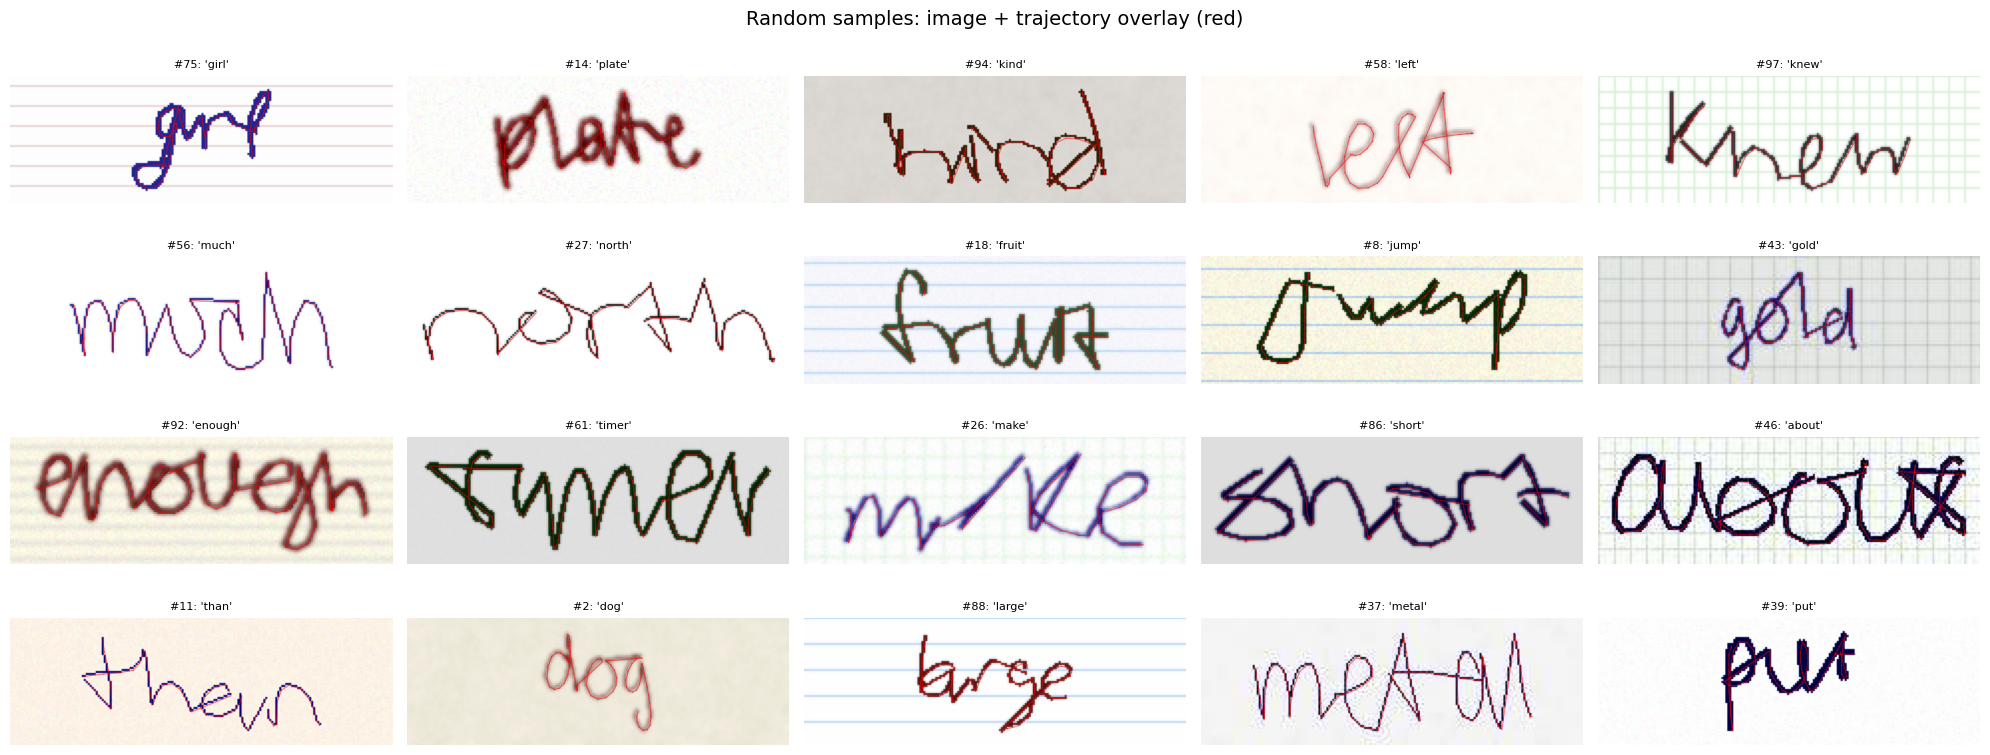

In [ ]:
# --- Visual validation: random samples with trajectory overlay ---

fig, axes = plt.subplots(4, 5, figsize=(20, 8))
fig.suptitle("Random samples: image + trajectory overlay (red)", fontsize=14)

indices = random.sample(range(sample_idx), min(20, sample_idx))
for ax, idx in zip(axes.flat, indices):
    ax.imshow(all_images[idx])
    
    # Reconstruct trajectory from stored deltas and overlay
    traj = all_trajectories[idx]
    length = all_lengths[idx]
    traj = traj[:length]
    
    # Convert deltas back to absolute coords
    xy = np.cumsum(traj[:, :2], axis=0)
    pen = traj[:, 2]
    
    if len(xy) > 1:
        xy_min = xy.min(axis=0)
        xy_max = xy.max(axis=0)
        src_w = max(xy_max[0] - xy_min[0], 1e-6)
        src_h = max(xy_max[1] - xy_min[1], 1e-6)
        
        # Match render_strokes_on_image: aspect-ratio-preserving fit with padding
        pad = 8
        scale = min((IMG_W - 2 * pad) / src_w, (IMG_H - 2 * pad) / src_h)
        scaled_w = src_w * scale
        scaled_h = src_h * scale
        off_x = (IMG_W - scaled_w) / 2
        off_y = (IMG_H - scaled_h) / 2
        
        img_xy = (xy - xy_min) * scale + np.array([off_x, off_y])
        
        # Draw stroke segments
        for i in range(1, len(img_xy)):
            if pen[i-1] < 0.5:  # pen down
                ax.plot([img_xy[i-1, 0], img_xy[i, 0]], 
                       [img_xy[i-1, 1], img_xy[i, 1]], 
                       'r-', alpha=0.5, linewidth=0.8)
    
    ax.set_title(f"#{idx}: '{all_words[idx]}'", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

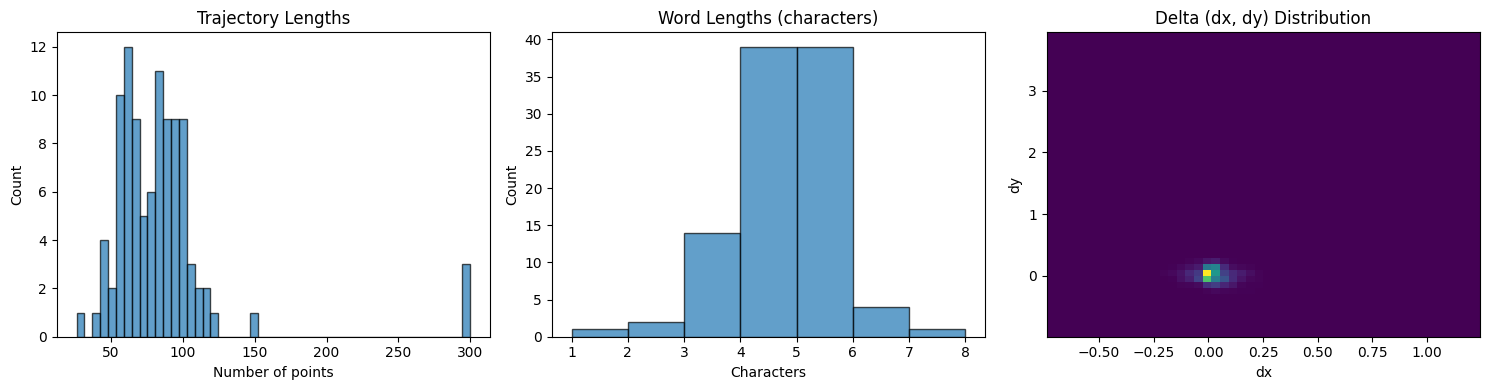

Trajectory length: mean=85.1, median=80, min=26, max=300
Word length: mean=4.3, range=[1, 7]


In [ ]:
# --- Distribution statistics ---

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Trajectory lengths
axes[0].hist(all_lengths[:sample_idx], bins=50, edgecolor="black", alpha=0.7)
axes[0].set_title("Trajectory Lengths")
axes[0].set_xlabel("Number of points")
axes[0].set_ylabel("Count")

# Word lengths
word_lens = [len(w) for w in all_words]
axes[1].hist(word_lens, bins=range(1, max(word_lens) + 2), edgecolor="black", alpha=0.7)
axes[1].set_title("Word Lengths (characters)")
axes[1].set_xlabel("Characters")
axes[1].set_ylabel("Count")

# Delta magnitudes
valid_trajs = all_trajectories[:sample_idx]
valid_lens = all_lengths[:sample_idx]
all_dx = np.concatenate([valid_trajs[i, :valid_lens[i], 0] for i in range(sample_idx)])
all_dy = np.concatenate([valid_trajs[i, :valid_lens[i], 1] for i in range(sample_idx)])
axes[2].hist2d(all_dx, all_dy, bins=50, cmap="viridis")
axes[2].set_title("Delta (dx, dy) Distribution")
axes[2].set_xlabel("dx")
axes[2].set_ylabel("dy")

plt.tight_layout()
plt.show()

print(f"Trajectory length: mean={all_lengths[:sample_idx].mean():.1f}, "
      f"median={np.median(all_lengths[:sample_idx]):.0f}, "
      f"min={all_lengths[:sample_idx].min()}, max={all_lengths[:sample_idx].max()}")
print(f"Word length: mean={np.mean(word_lens):.1f}, range=[{min(word_lens)}, {max(word_lens)}]")

## 9. Quick-Load Test

Verify that the saved dataset can be loaded and used for training.

images:       (100, 64, 192, 3), dtype=uint8
trajectories: (100, 300, 3), dtype=float32
lengths:      (100,), dtype=int32
words:        (100,)


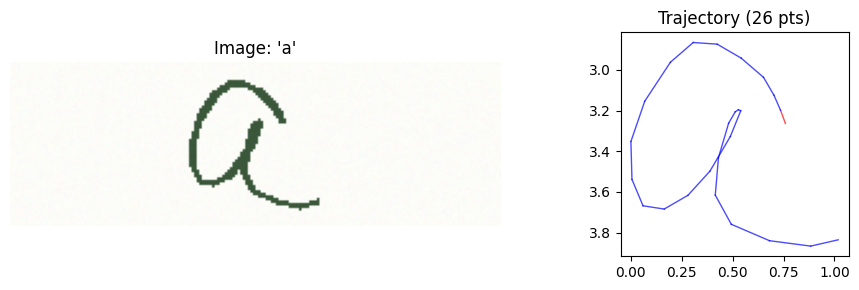


Dataset ready for training at: /Users/artemlukoyanov/Documents/Proga/Ilumni/playground/SundaiClub/weeks/inkai/ink-ai-hack-playground/notebooks/data/generated


In [ ]:
# Reload from disk to verify
ds = np.load(os.path.join(OUTPUT_DIR, "dataset.npz"), allow_pickle=True)
print(f"images:       {ds['images'].shape}, dtype={ds['images'].dtype}")
print(f"trajectories: {ds['trajectories'].shape}, dtype={ds['trajectories'].dtype}")
print(f"lengths:      {ds['lengths'].shape}, dtype={ds['lengths'].dtype}")
print(f"words:        {ds['words'].shape}")

# Show a sample from loaded data
idx = random.randint(0, len(ds['images']) - 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

ax1.imshow(ds['images'][idx])
ax1.set_title(f"Image: '{ds['words'][idx]}'")
ax1.axis("off")

# Plot trajectory
traj = ds['trajectories'][idx][:ds['lengths'][idx]]
xy = np.cumsum(traj[:, :2], axis=0)
pen = traj[:, 2]
for i in range(1, len(xy)):
    color = 'blue' if pen[i-1] == 0 else 'red'
    ax2.plot([xy[i-1, 0], xy[i, 0]], [xy[i-1, 1], xy[i, 1]], 
            color=color, linewidth=1, alpha=0.7)
ax2.set_title(f"Trajectory ({ds['lengths'][idx]} pts)")
ax2.invert_yaxis()
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

print(f"\nDataset ready for training at: {OUTPUT_DIR}")